In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key=os.getenv("GROQ_API_KEY")

if not api_key:
    print("the key is not present")
else:
    print("the key is present")

the key is present


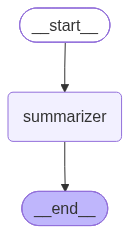

In [6]:
from langchain_groq import ChatGroq
from typing import TypedDict
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
import os

class workflowSchema(TypedDict):
    topic: str
    summary:str

llm=ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="openai/gpt-oss-120b"
)

def summarize_workflow(topic: str):
    response = llm.invoke([
        SystemMessage(
            content=(
                "You are a technical researcher. "
                "Explain the topic accurately for a "
                "developer who knows basic programming."
            )
        ),
        HumanMessage(
            content=f"Research this topic: {topic}"
        )
    ])
    return{
        "topic": topic,
        "summary": response.content
    }


research_builder=StateGraph(workflowSchema)

research_builder.add_node("summarizer", summarize_workflow)
research_builder.add_edge(START,"summarizer")
research_builder.add_edge("summarizer",END)

Image(research_builder)

summarizer_subgraph=research_builder.compile()  
display(summarizer_subgraph)


@tool
def summarize_workflow_tool(topic: str):
    '''Summarize the given topic using the summarize_workflow function.'''
    return summarize_workflow(topic)


tools = [summarize_workflow_tool]
llm_with_tools=llm.bind_tools(tools)








In [ ]:
from typing import TypedDict
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
class ParentState(TypedDict):
    messages: list


# =========================================================
# 5. Parent LLM node
# =========================================================

def call_llm(state: ParentState):
    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }


# =========================================================
# 6. Tool execution node
# =========================================================

tool_node = ToolNode(tools)


# =========================================================
# 7. Build the parent workflow
# =========================================================

parent_builder = StateGraph(ParentState)

parent_builder.add_node(
    "llm",
    call_llm
)

parent_builder.add_node(
    "tools",
    tool_node
)

parent_builder.add_edge(
    START,
    "llm"
)

parent_builder.add_conditional_edges(
    "llm",
    tools_condition
)

parent_builder.add_edge(
    "tools",
    "llm"
)

parent_workflow = parent_builder.compile()


# =========================================================
# 8. Run the parent workflow
# =========================================================

result = parent_workflow.invoke({
    "messages": [
        HumanMessage(
            content="Explain JSON RPC call"
        )
    ]
})

print(result["messages"][-1].content)

**Artificial Intelligence (AI)** is a broad field of computer science that aims to create machines capable of performing tasks that, when done by humans, require intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity. AI systems range from simple rule‑based programs to complex neural networks that can generate art or drive cars.

Below is a structured overview that covers the key ideas, history, techniques, applications, challenges, and future directions of AI.

---

## 1. Core Definition

| Aspect | What It Means |
|--------|---------------|
| **Intelligence** | The ability to acquire knowledge, adapt to new situations, understand complex ideas, and apply reasoning to achieve goals. |
| **Artificial** | Implemented in machines—software, hardware, or a combination—rather than in biological organisms. |
| **Goal** | Build systems that can **perceive**, **reason**, **learn**, **plan**, **communicate**, and **act** a

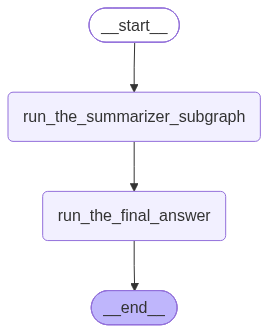

Topic: Model Context Protocol

Summary:
## Model Context Protocol (MCP) – A Technical Overview for Developers  

### 1. What Is the Model Context Protocol?

The **Model Context Protocol (MCP)** is a lightweight, language‑agnostic specification for **exchanging, persisting, and manipulating the “context” that a machine‑learning model (especially large language models, LLMs) needs to produce coherent, stateful outputs**.  

- **Context** = the set of tokens, embeddings, metadata, and auxiliary state that a model consumes in a single inference pass.  
- **Protocol** = a set of JSON‑based message schemas, transport conventions (HTTP, WebSocket, gRPC), and optional cryptographic signing that lets clients and services agree on *what* context is, *how* it is versioned, and *how* it is updated.

MCP was first formalised in the **OpenAI‑MCP Working Group (2023‑2024)** and has since been adopted by several LLM‑as‑a‑service providers (OpenAI, Anthropic, Cohere) and open‑source runtimes (vLLM, Tex

In [8]:
# Parent graph
from IPython.display import display
class ParentWorkflowSchema(TypedDict):
    summary: str
    topic: str
    final_answer: str


def run_summarizer_subgraph(state: ParentWorkflowSchema):
    result = summarizer_subgraph.invoke({
        "topic": state["topic"],
        "summary": ""
    })

    return {
        "summary": result["summary"]
    }


def run_final_answer(state: ParentWorkflowSchema):
    return {
        "final_answer": (
            f"Topic: {state['topic']}\n\n"
            f"Summary:\n{state['summary']}"
        )
    }


parent_builder = StateGraph(ParentWorkflowSchema)

parent_builder.add_node(
    "run_the_summarizer_subgraph",
    run_summarizer_subgraph
)

parent_builder.add_node(
    "run_the_final_answer",
    run_final_answer
)

parent_builder.add_edge(
    START,
    "run_the_summarizer_subgraph"
)

parent_builder.add_edge(
    "run_the_summarizer_subgraph",
    "run_the_final_answer"
)

parent_builder.add_edge(
    "run_the_final_answer",
    END
)

parent_workflow = parent_builder.compile()
display(parent_workflow)

result = parent_workflow.invoke({
    "topic": "Model Context Protocol",
    "summary": "",
    "final_answer": ""
})

print(result["final_answer"])

In [5]:
import os
from typing import TypedDict

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


# =========================================================
# LLM
# =========================================================

llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model="openai/gpt-oss-120b",
    temperature=0
)


# =========================================================
# SUBGRAPH
# =========================================================

class SubgraphState(TypedDict):
    topic: str
    summary: str


def summarize_node(state: SubgraphState):
    response = llm.invoke([
        SystemMessage(
            content="Summarize the topic for a beginner developer."
        ),
        HumanMessage(
            content=f"Summarize: {state['topic']}"
        )
    ])

    return {
        "summary": response.content
    }


subgraph_builder = StateGraph(SubgraphState)

subgraph_builder.add_node(
    "summarize",
    summarize_node
)

subgraph_builder.add_edge(START, "summarize")
subgraph_builder.add_edge("summarize", END)

summarizer_subgraph = subgraph_builder.compile()


# =========================================================
# TOOL THAT CALLS THE SUBGRAPH
# =========================================================

@tool
def summarize_topic(topic: str) -> str:
    """Run the complete summarizer subgraph for a topic."""

    result = summarizer_subgraph.invoke({
        "topic": topic,
        "summary": ""
    })

    return result["summary"]


tools = [summarize_topic]
llm_with_tools = llm.bind_tools(tools)


# =========================================================
# PARENT GRAPH
# =========================================================

class ParentState(TypedDict):
    messages: list


def call_llm(state: ParentState):
    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": state["messages"] + [response]
    }


parent_builder = StateGraph(ParentState)

parent_builder.add_node("llm", call_llm)
parent_builder.add_node("tools", ToolNode(tools))

parent_builder.add_edge(START, "llm")

parent_builder.add_conditional_edges(
    "llm",
    tools_condition
)

parent_builder.add_edge("tools", "llm")

parent_graph = parent_builder.compile()


# =========================================================
# RUN PARENT GRAPH
# =========================================================

result = parent_graph.invoke({
    "messages": [
        HumanMessage(
            content="Explain Artificial Intelligence"
        )
    ]
})

print(result["messages"][-1].content)

**Artificial Intelligence (AI)** is a branch of computer science that aims to create machines capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity. Below is a structured overview that captures the essence of AI, its main approaches, and its impact today.

---

## 1. Core Definition
- **AI** = **the design of algorithms and systems that can perceive their environment, reason about it, and act to achieve goals**—often in ways that mimic or exceed human performance.

---

## 2. Historical Milestones
| Era | Key Developments | Significance |
|-----|------------------|--------------|
| **1940s‑1950s** | Turing Test (Alan Turing), early neural nets (McCulloch‑Pitts), first AI programs (Logic Theorist) | Laid philosophical and technical foundations. |
| **1956** | Dartmouth Workshop (coined “Artificial Intelligence”) | Formal birth of AI as a research field. |
| *

In [3]:
import os
os.getenv("LANGSMITH_PROJECT")

'my-deep-agent'

ValueError: Invalid input type <class 'dict'>. Must be a PromptValue, str, or list of BaseMessages.